In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [4]:
df = pd.read_csv('dataset.csv')

In [6]:
df.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1.0,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1.0,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1.0,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1.0,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1.0,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [8]:
df.shape

(1195, 24)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1195 non-null   object 
 1   MDVP:Fo(Hz)       1195 non-null   float64
 2   MDVP:Fhi(Hz)      1195 non-null   float64
 3   MDVP:Flo(Hz)      1195 non-null   float64
 4   MDVP:Jitter(%)    1195 non-null   float64
 5   MDVP:Jitter(Abs)  1195 non-null   float64
 6   MDVP:RAP          1195 non-null   float64
 7   MDVP:PPQ          1195 non-null   float64
 8   Jitter:DDP        1195 non-null   float64
 9   MDVP:Shimmer      1195 non-null   float64
 10  MDVP:Shimmer(dB)  1195 non-null   float64
 11  Shimmer:APQ3      1195 non-null   float64
 12  Shimmer:APQ5      1195 non-null   float64
 13  MDVP:APQ          1195 non-null   float64
 14  Shimmer:DDA       1195 non-null   float64
 15  NHR               1195 non-null   float64
 16  HNR               1195 non-null   float64


In [40]:
df["status"] = df["status"].astype(int)

In [42]:
X = df.drop(['name','status'], axis=1)
y = df['status']

## Train - Test split

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

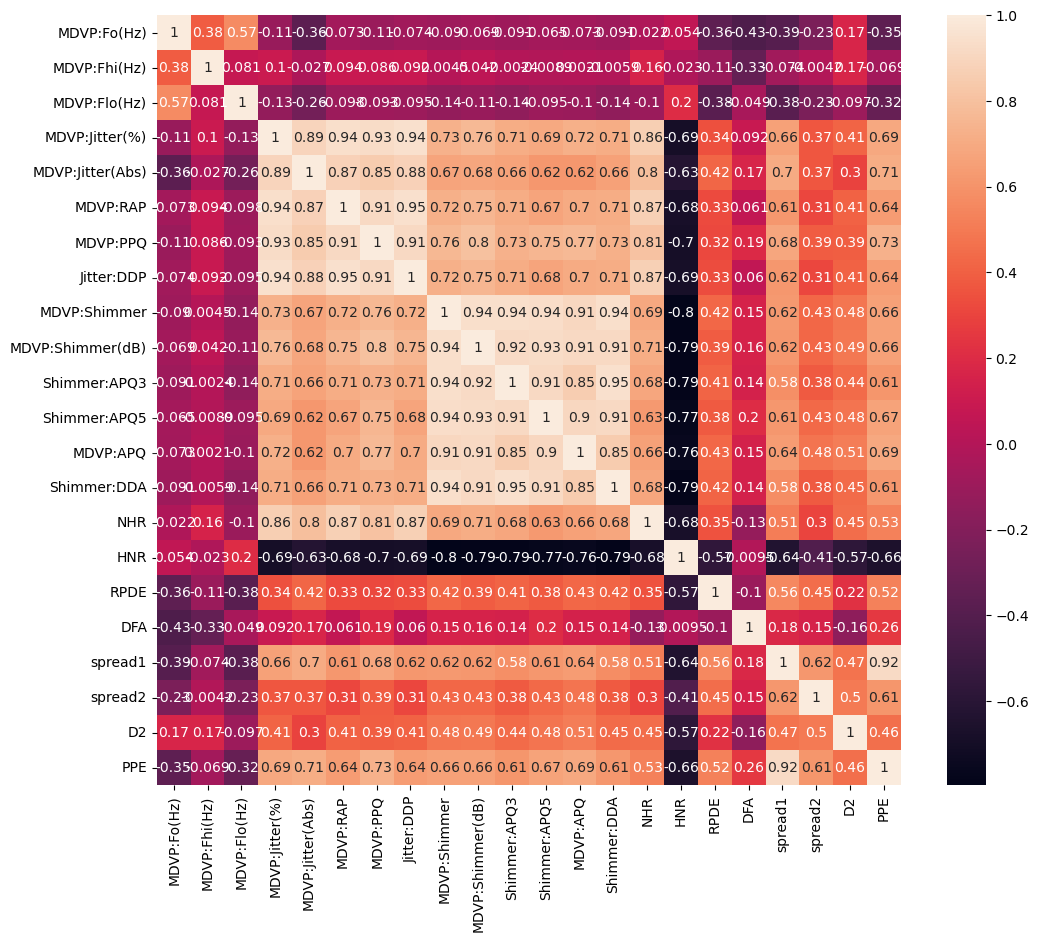

In [46]:
plt.figure(figsize=(12,10))
corr = X.corr()
sns.heatmap(corr,annot=True)
plt.show()

## Model Building

In [48]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
from sklearn.decomposition import PCA
pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [54]:
models={
    "Logisitic Regression":LogisticRegression(),
    "SVC(Linear)":SVC(kernel='linear'),
    "SVC(rbf)":SVC(kernel='rbf'),
    "SVC(poly)":SVC(kernel='poly'),
    "SVC(sigmoid)":SVC(kernel='sigmoid'),
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_pca, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train_pca)
    y_test_pred = model.predict(X_test_pca)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    
    print('----------------------------------')

    print("Confusion matrix")
    print(confusion_matrix(y_test,y_test_pred))
    
    print('----------------------------------')
    print("Classification report")
    print(classification_report(y_test,y_test_pred))

    
    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.9184
- F1 score: 0.9008
- Precision: 1.0000
- Recall: 0.3554
- Roc Auc Score: 0.6777
----------------------------------
Model performance for Test set
- Accuracy: 0.9205
- F1 score: 0.8993
- Precision: 1.0000
- Recall: 0.2692
- Roc Auc Score: 0.6346
----------------------------------
Confusion matrix
[[213   0]
 [ 19   7]]
----------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       213
           1       1.00      0.27      0.42        26

    accuracy                           0.92       239
   macro avg       0.96      0.63      0.69       239
weighted avg       0.93      0.92      0.90       239



SVC(Linear)
Model performance for Training set
- Accuracy: 0.9268
- F1 score: 0.9134
- Precision: 1.0000
- Recall: 0.4215
- Roc Auc Score: 0.7107
----------------------------------
Model performance for Test set
- Accur

In [64]:
models={
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "XgBoost":XGBClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))
    
    print('----------------------------------')

    print("Confusion matrix")
    print(confusion_matrix(y_test,y_test_pred))
    
    print('----------------------------------')
    print("Classification report")
    print(classification_report(y_test,y_test_pred))

    
    print('='*35)
    print('\n')

Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9791
- F1 score: 0.9796
- Precision: 0.8621
- Recall: 0.9615
- Roc Auc Score: 0.9714
----------------------------------
Confusion matrix
[[209   4]
 [  1  25]]
----------------------------------
Classification report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       213
           1       0.86      0.96      0.91        26

    accuracy                           0.98       239
   macro avg       0.93      0.97      0.95       239
weighted avg       0.98      0.98      0.98       239



Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Adaboost
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9623
- F1 score: 0.9627
- Precision: 0.8148
- Recall: 0.8462
- Roc Auc Score: 0.9113
----------------------------------
Confusion matrix
[[208   5]
 [  4  22]]
----------------------------------
Classification report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       213
           1       0.81      0.85      0.83        26

    accuracy                           0.96       239
   macro avg       0.90      0.91      0.90       239
weighted avg       0.96      0.96      0.96       239



XgBoost
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- Roc Auc Score: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9874
- F1

In [66]:
rf = RandomForestClassifier()
rf.fit(X_train_scaled,y_train)
y_pred = rf.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[210   0]
 [  3  26]]
0.9874476987447699
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       210
           1       1.00      0.90      0.95        29

    accuracy                           0.99       239
   macro avg       0.99      0.95      0.97       239
weighted avg       0.99      0.99      0.99       239



In [72]:
xg = XGBClassifier()
xg.fit(X_train_scaled,y_train)
y_pred = xg.predict(X_test_scaled)
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[210   0]
 [  3  26]]
0.9874476987447699
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       210
           1       1.00      0.90      0.95        29

    accuracy                           0.99       239
   macro avg       0.99      0.95      0.97       239
weighted avg       0.99      0.99      0.99       239



In [70]:
from sklearn.model_selection import cross_val_score

print(cross_val_score(rf, X_test, y_test, cv=5).mean())

0.9624113475177305


In [74]:
from sklearn.model_selection import cross_val_score

print(cross_val_score(xg, X_test, y_test, cv=5).mean())

0.9624113475177305


## Saving the model

In [76]:
import pickle
pickle.dump(xg,open('Parkinson_disease_model.pkl','wb'))
pickle.dump(scaler,open('Parkinson_disease_scaler.pkl','wb'))